In [ ]:
!pip -q install pymupdf sentence-transformers faiss-cpu transformers accelerate

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import pymupdf
import faiss

from sentence_transformers import SentenceTransformer
from transformers import pipeline

In [ ]:
from google.colab import files

uploaded = files.upload()

pdf_files = list(uploaded.keys())

print("Uploaded PDF files:")

for file in pdf_files:
    print("-", file)

Saving Artificial-Intelligence-1.pdf to Artificial-Intelligence-1 (1).pdf
Saving MACHINE LEARNING(R17A0534).pdf to MACHINE LEARNING(R17A0534) (1).pdf
Uploaded PDF files:
- Artificial-Intelligence-1 (1).pdf
- MACHINE LEARNING(R17A0534) (1).pdf


In [ ]:
print("Number of PDFs uploaded:", len(pdf_files))

for file in pdf_files:
    print(file)

Number of PDFs uploaded: 2
Artificial-Intelligence-1 (1).pdf
MACHINE LEARNING(R17A0534) (1).pdf


In [ ]:
def extract_text_from_pdf(pdf_path):

    document = pymupdf.open(pdf_path)

    pages = []

    for page_number, page in enumerate(document):

        text = page.get_text()

        pages.append({
            "page": page_number + 1,
            "text": text
        })

    document.close()

    return pages

In [ ]:
pymupdf.open()

Document('None')

In [ ]:
documents = []

for pdf_file in pdf_files:

    pages = extract_text_from_pdf(pdf_file)

    for page in pages:

        documents.append({
            "source": pdf_file,
            "page": page["page"],
            "text": page["text"]
        })

print("Total pages extracted:", len(documents))

Total pages extracted: 148


In [ ]:
for document in documents[:3]:

    print("=" * 80)

    print("SOURCE:", document["source"])
    print("PAGE:", document["page"])

    print("=" * 80)

    print(document["text"][:1500])

    print()

SOURCE: Artificial-Intelligence-1 (1).pdf
PAGE: 1
Natural Language Processing
Computers are great at working with standardized and structured data like
database tables and financial records. They are able to process that data much faster than
we humans can. But we humans don’t communicate in “structured data” nor do we speak
binary! We communicate using words, a form of unstructured data.
Unfortunately, computers suck at working with unstructured data because there are
no standardized techniques to process it. When we program computers using something
like C++, Java, or Python, we are essentially giving the computer a set of rules that it should
operate by. With unstructured data, these rules are quite abstract and challenging to define
concretely.
There’s a lot of unstructured natural language on the internet; sometimes even
Google doesn’t know what you’re searching for!
Human vs Computer understanding of language
Humans have been writing things down for thousands of years. Over that 

In [ ]:
def clean_text(text):

    text = text.replace("\n", " ")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
for document in documents:

    document["text"] = clean_text(
        document["text"]
    )

print("Text cleaning completed.")

Text cleaning completed.


In [ ]:
documents = [
    document
    for document in documents
    if len(document["text"]) > 50
]

print("Pages remaining:", len(documents))

Pages remaining: 146


In [ ]:
def create_chunks(
    text,
    chunk_size=800,
    overlap=150
):

    chunks = []

    start = 0

    while start < len(text):

        end = start + chunk_size

        chunk = text[start:end].strip()

        if chunk:
            chunks.append(chunk)

        start += chunk_size - overlap

    return chunks

In [ ]:
chunks = []

for document in documents:

    page_chunks = create_chunks(
        document["text"]
    )

    for chunk in page_chunks:

        chunks.append({
            "text": chunk,
            "source": document["source"],
            "page": document["page"]
        })

print("Total chunks:", len(chunks))

Total chunks: 503


In [ ]:
for i in range(min(5, len(chunks))):

    print("=" * 80)

    print("CHUNK:", i + 1)
    print("SOURCE:", chunks[i]["source"])
    print("PAGE:", chunks[i]["page"])

    print("\nTEXT:")
    print(chunks[i]["text"][:1000])

CHUNK: 1
SOURCE: Artificial-Intelligence-1 (1).pdf
PAGE: 1

TEXT:
Natural Language Processing Computers are great at working with standardized and structured data like database tables and financial records. They are able to process that data much faster than we humans can. But we humans don’t communicate in “structured data” nor do we speak binary! We communicate using words, a form of unstructured data. Unfortunately, computers suck at working with unstructured data because there are no standardized techniques to process it. When we program computers using something like C++, Java, or Python, we are essentially giving the computer a set of rules that it should operate by. With unstructured data, these rules are quite abstract and challenging to define concretely. There’s a lot of unstructured natural language on the internet; sometimes even Google doesn
CHUNK: 2
SOURCE: Artificial-Intelligence-1 (1).pdf
PAGE: 1

TEXT:
s are quite abstract and challenging to define concretely. There’s 

In [ ]:
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [ ]:
texts = [
    chunk["text"]
    for chunk in chunks
]

embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True
)

embeddings = np.array(
    embeddings
).astype("float32")

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding shape: (503, 384)


In [ ]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(
    dimension
)

index.add(embeddings)

print("FAISS vector database created.")
print("Number of vectors:", index.ntotal)

FAISS vector database created.
Number of vectors: 503


In [ ]:
def retrieve_documents(
    question,
    top_k=5
):

    question_embedding = embedding_model.encode(
        [question]
    )

    question_embedding = np.array(
        question_embedding
    ).astype("float32")

    distances, indices = index.search(
        question_embedding,
        top_k
    )

    results = []

    for distance, idx in zip(
        distances[0],
        indices[0]
    ):

        if idx < len(chunks):

            results.append({
                "text": chunks[idx]["text"],
                "source": chunks[idx]["source"],
                "page": chunks[idx]["page"],
                "distance": float(distance)
            })

    return results

In [ ]:
question = "What is machine learning?"

results = retrieve_documents(
    question,
    top_k=5
)

for i, result in enumerate(results):

    print("=" * 80)

    print("RESULT:", i + 1)
    print("SOURCE:", result["source"])
    print("PAGE:", result["page"])
    print("DISTANCE:", result["distance"])

    print("\nTEXT:")
    print(result["text"][:1000])

RESULT: 1
SOURCE: MACHINE LEARNING(R17A0534) (1).pdf
PAGE: 6
DISTANCE: 0.2920018434524536

TEXT:
1 UNIT I Introduction to Machine Learning 1. Introduction 1.1 What Is Machine Learning? Machine learning is programming computers to optimize a performance criterion using example data or past experience. We have a model defined up to some parameters, and learning is the execution of a computer program to optimize the parameters of the model using the training data or past experience. The model may be predictive to make predictions in the future, or descriptive to gain knowledge from data, or both. Arthur Samuel, an early American leader in the field of computer gaming and artificial intelligence, coined the term “Machine Learning” in 1959 while at IBM. He defined machine learning as “the field of study that gives computers the ability to learn without being explicitly programmed.” However
RESULT: 2
SOURCE: MACHINE LEARNING(R17A0534) (1).pdf
PAGE: 6
DISTANCE: 0.48042479157447815

TEXT:
ile 

In [ ]:
question = "What are the types of learning?"

results = retrieve_documents(
    question,
    top_k=5
)

for i, result in enumerate(results):

    print("=" * 80)

    print("RESULT:", i + 1)
    print("SOURCE:", result["source"])
    print("PAGE:", result["page"])

    print("\nTEXT:")
    print(result["text"][:800])

RESULT: 1
SOURCE: MACHINE LEARNING(R17A0534) (1).pdf
PAGE: 98

TEXT:
training examples and
RESULT: 2
SOURCE: MACHINE LEARNING(R17A0534) (1).pdf
PAGE: 8

TEXT:
raining examples. Concept learning forms the basis of both tree-based and rule-based models. More formally, Concept Learning involves acquiring the definition of a general category from a given set of positive and negative training examples of the category. A Formal Definition for Concept Learning is “The inferring of a Boolean-valued function from training examples of its input and output.” In concept learning, we only learn a description for the positive class and label everything that doesn’t satisfy that description as negative.
RESULT: 3
SOURCE: Artificial-Intelligence-1 (1).pdf
PAGE: 20

TEXT:
s type of learning is done without the supervision of a teacher. This learning process is independent. During the training of ANN under unsupervised learning, the input vectors of similar type are combined to form clusters. When a new

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("FLAN-T5 model loaded successfully.")

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 model loaded successfully.


In [ ]:
def generate_answer(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=200
    )

    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return answer

In [ ]:
def ask_rag(question, top_k=5):

    retrieved_documents = retrieve_documents(
        question,
        top_k=top_k
    )

    prompt = create_prompt(
        question,
        retrieved_documents
    )

    answer = generate_answer(prompt)

    return answer, retrieved_documents

In [ ]:
question = "What is machine learning?"

def create_prompt(question, retrieved_documents):
    context = "\n".join([doc["text"] for doc in retrieved_documents])
    prompt = f"""Context: {context}

Question: {question}

Answer:"""
    return prompt

answer, sources = ask_rag(question)

print("QUESTION:")
print(question)

print("\nANSWER:")
print(answer)

print("\nSOURCES:")

for source in sources:
    print(
        f"- {source['source']} "
        f"(Page {source['page']})"
    )

QUESTION:
What is machine learning?

ANSWER:
Machine Learning is a subset of Artificial Intelligence which provides computers with the ability to learn without being explicitly programmed.

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf (Page 6)
- MACHINE LEARNING(R17A0534) (1).pdf (Page 6)
- Artificial-Intelligence-1 (1).pdf (Page 10)
- MACHINE LEARNING(R17A0534) (1).pdf (Page 19)
- MACHINE LEARNING(R17A0534) (1).pdf (Page 7)


In [ ]:
print("QUESTION:")
print(question)

print("\nANSWER:")
print(answer)

print("\nSOURCES:")

for source in sources:

    print(
            f"- {source['source']} "
                    f"(Page {source['page']})"
                        )

QUESTION:
What is machine learning?

ANSWER:
Machine Learning is a subset of Artificial Intelligence which provides computers with the ability to learn without being explicitly programmed.

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf (Page 6)
- MACHINE LEARNING(R17A0534) (1).pdf (Page 6)
- Artificial-Intelligence-1 (1).pdf (Page 10)
- MACHINE LEARNING(R17A0534) (1).pdf (Page 19)
- MACHINE LEARNING(R17A0534) (1).pdf (Page 7)


In [ ]:
questions = [
    "What is artificial intelligence?",
    "What are algorithms?",
    "What are the types of artificial intelligence?",
    "What is generative AI?"
]

for question in questions:
    answer, sources = ask_rag(question)

    print("=" * 80)
    print("QUESTION:")
    print(question)

    print("\nANSWER:")
    print(answer)

    print("\nSOURCES:")

    unique_sources = set()
    for source in sources:
        unique_sources.add(f"{source['source']} - Page {source['page']}")

    for source in unique_sources:
        print("-", source)

    print()

QUESTION:
What is artificial intelligence?

ANSWER:
iii.

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf - Page 46
- MACHINE LEARNING(R17A0534) (1).pdf - Page 6
- Artificial-Intelligence-1 (1).pdf - Page 10

QUESTION:
What are algorithms?

ANSWER:
SSCASC

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf - Page 115
- MACHINE LEARNING(R17A0534) (1).pdf - Page 6
- Artificial-Intelligence-1 (1).pdf - Page 10

QUESTION:
What are the types of artificial intelligence?

ANSWER:
A training set of examples

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf - Page 46
- Artificial-Intelligence-1 (1).pdf - Page 10
- MACHINE LEARNING(R17A0534) (1).pdf - Page 17
- MACHINE LEARNING(R17A0534) (1).pdf - Page 47
- MACHINE LEARNING(R17A0534) (1).pdf - Page 48

QUESTION:
What is generative AI?

ANSWER:
Reinforcement Learning

SOURCES:
- Artificial-Intelligence-1 (1).pdf - Page 13
- Artificial-Intelligence-1 (1).pdf - Page 10
- MACHINE LEARNING(R17A0534) (1).pdf - Page 11
- Artificial-Intelligence-1 (1).pdf - Page 

In [ ]:
questions = [
    "What is supervised learning?",
    "What is unsupervised learning?",
    "What is reinforcement learning?",
    "What is a decision tree?",
    "What is a neural network?",
    "What is clustering?"
]

for question in questions:
    answer, sources = ask_rag(question)

    print("=" * 80)
    print("QUESTION:")
    print(question)

    print("\nANSWER:")
    print(answer)

    print("\nSOURCES:")

    unique_sources = set()
    for source in sources:
        unique_sources.add(f"{source['source']} - Page {source['page']}")

    for source in unique_sources:
        print("-", source)

    print()

QUESTION:
What is supervised learning?

ANSWER:
supervised learning is a function that maps an input to an output based on example input-output pairs.

SOURCES:
- Artificial-Intelligence-1 (1).pdf - Page 20
- MACHINE LEARNING(R17A0534) (1).pdf - Page 61
- MACHINE LEARNING(R17A0534) (1).pdf - Page 17
- MACHINE LEARNING(R17A0534) (1).pdf - Page 19

QUESTION:
What is unsupervised learning?

ANSWER:
unsupervised learning is helpful for finding useful insights from the data

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf - Page 59
- MACHINE LEARNING(R17A0534) (1).pdf - Page 61
- MACHINE LEARNING(R17A0534) (1).pdf - Page 58
- MACHINE LEARNING(R17A0534) (1).pdf - Page 18

QUESTION:
What is reinforcement learning?

ANSWER:
Reinforcement Learning is similar to supervised learning; however we might have very less information. During the training of network under reinforcement learning, the network receives some feedback from the environment. This makes it somewhat similar to supervised learning. 

In [ ]:
while True:

    question = input(
        "\nAsk a question "
        "(type 'exit' to stop): "
    )

    if question.lower() == "exit":

        print("RAG system stopped.")

        break

    answer, sources = ask_rag(
        question
    )

    print("\nANSWER:")
    print(answer)

    print("\nSOURCES:")

    unique_sources = set()

    for source in sources:

        unique_sources.add(
            f"{source['source']} - Page {source['page']}"
        )

    for source in unique_sources:

        print("-", source)


Ask a question (type 'exit' to stop): What is ai 

ANSWER:
ANNs are a flourishing science branch.

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf - Page 46
- MACHINE LEARNING(R17A0534) (1).pdf - Page 45
- Artificial-Intelligence-1 (1).pdf - Page 10
- MACHINE LEARNING(R17A0534) (1).pdf - Page 48

Ask a question (type 'exit' to stop): What is ml

ANSWER:
Arthur Samuel (born 1890) is a computer scientist and entrepreneur.

SOURCES:
- MACHINE LEARNING(R17A0534) (1).pdf - Page 80
- MACHINE LEARNING(R17A0534) (1).pdf - Page 6
- MACHINE LEARNING(R17A0534) (1).pdf - Page 45
- MACHINE LEARNING(R17A0534) (1).pdf - Page 16
- MACHINE LEARNING(R17A0534) (1).pdf - Page 79

Ask a question (type 'exit' to stop): Exit
RAG system stopped.


In [ ]:
question = "Who is the President of France?"

answer, sources = ask_rag(
    question
)

print("QUESTION:")
print(question)

print("\nANSWER:")
print(answer)

QUESTION:
Who is the President of France?

ANSWER:
Nicolas Sarkozy


In [ ]:
evaluation_questions = [

    "What is machine learning?",

    "What are the types of learning?",

    "What is supervised learning?",

    "What is artificial intelligence?",

    "What are algorithms?",

    "What is generative AI?"

]

In [ ]:
evaluation_results = []

for question in evaluation_questions:

    answer, sources = ask_rag(
        question
    )

    source_names = set()

    for source in sources:

        source_names.add(
            f"{source['source']} - Page {source['page']}"
        )

    evaluation_results.append({

        "Question": question,

        "Answer": answer,

        "Sources": "; ".join(
            source_names
        )

    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df

,Question,Answer,Sources
0,What is machine learning?,Machine Learning is a subset of Artificial Int...,MACHINE LEARNING(R17A0534) (1).pdf - Page 7; M...
1,What are the types of learning?,How much training data is sufficient?,MACHINE LEARNING(R17A0534) (1).pdf - Page 8; M...
2,What is supervised learning?,supervised learning is a function that maps an...,Artificial-Intelligence-1 (1).pdf - Page 20; M...
3,What is artificial intelligence?,iii.,MACHINE LEARNING(R17A0534) (1).pdf - Page 46; ...
4,What are algorithms?,SSCASC,MACHINE LEARNING(R17A0534) (1).pdf - Page 115;...
5,What is generative AI?,Reinforcement Learning,Artificial-Intelligence-1 (1).pdf - Page 13; A...


In [ ]:
evaluation_df.to_csv(
    "rag_evaluation_results.csv",
    index=False
)

print(
    "Evaluation results saved."
)

Evaluation results saved.


In [ ]:
chunks_df = pd.DataFrame(
    chunks
)

chunks_df.to_csv(
    "document_chunks.csv",
    index=False
)

print(
    "Document chunks saved."
)

Document chunks saved.


In [ ]:
faiss.write_index(
    index,
    "rag_faiss_index.faiss"
)

print(
    "FAISS index saved."
)

FAISS index saved.


In [ ]:
files.download(
    "rag_evaluation_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    "document_chunks.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    "rag_faiss_index.faiss"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

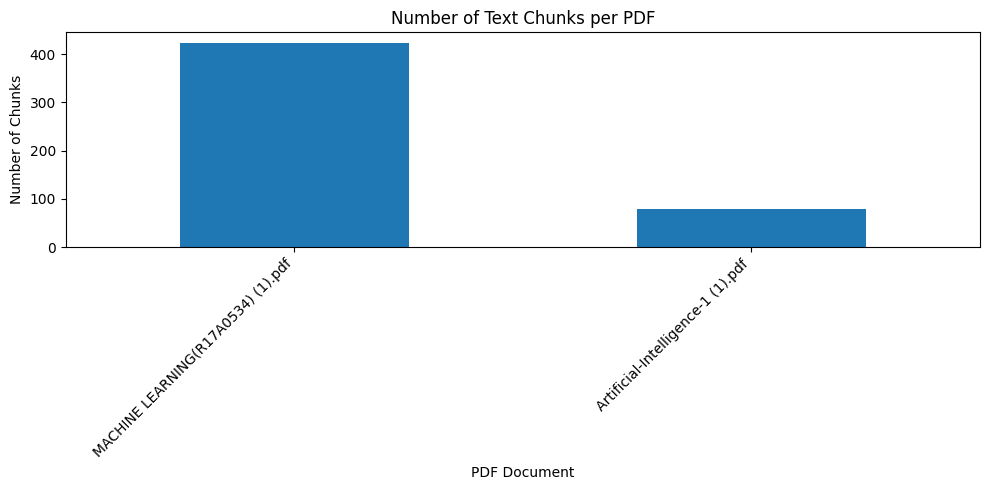

In [ ]:
import matplotlib.pyplot as plt

source_counts = pd.Series(
    [
        chunk["source"]
        for chunk in chunks
    ]
).value_counts()

source_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Number of Text Chunks per PDF"
)

plt.xlabel("PDF Document")
plt.ylabel("Number of Chunks")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()